In [12]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
path = kagglehub.dataset_download("ajeetkumar20/cicids-2017")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ajeetkumar20/cicids-2017


Starting data loading...
Data loaded successfully. Total rows: 2830743, Total columns: 79
Cleaning data...
Preparing labels and features...
Scaling features...
Training the Decision Tree model (this might take a minute)...
Making predictions on the test set...

=== Model Performance ===
Accuracy:  0.9988
Precision: 0.9969
Recall:    0.9968
F1-score:  0.9968


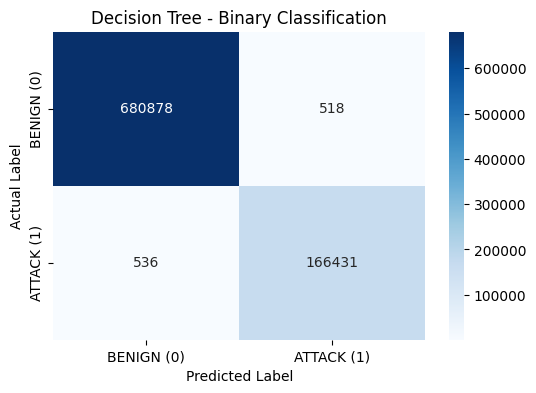

In [13]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting data loading...")

# 1. Locate all CSV files in the dataset directory
dataset_path = '/kaggle/input/datasets/ajeetkumar20/cicids-2017'
csv_files = glob.glob(os.path.join(dataset_path, "**/*.csv"), recursive=True)

# 2. Combine all daily CSVs into one massive DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)
print(f"Data loaded successfully. Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

# 3. Data Cleaning
print("Cleaning data...")
# Remove leading/trailing whitespaces from column names (a known issue in CICIDS2017)
df.columns = df.columns.str.strip()

# Replace Infinity values with NaN, then drop any rows with NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 4. Label Engineering (Binary Classification)
# The paper tests Binary classification: BENIGN vs ATTACK
print("Preparing labels and features...")
# Convert 'BENIGN' to 0, and any other attack type to 1
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Separate features (X) and target (y)
X = df.drop(columns=['Label'])
y = df['Label']

from sklearn.preprocessing import StandardScaler

# 4.5 Apply Standard Scaling to match the paper's methodology
print("Scaling features...")
scaler = StandardScaler()

# Keep BOTH column names AND original index intact
X_scaled = pd.DataFrame(
    scaler.fit_transform(X), 
    columns=X.columns, 
    index=X.index  # <-- This is the crucial addition
)

# Now, use X_scaled for your train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# # 5. Train-Test Split
# # Splitting the data: 70% for training, 30% for testing
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 6. Train the Decision Tree Model
print("Training the Decision Tree model (this might take a minute)...")
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# 7. Make Predictions
print("Making predictions on the test set...")
y_pred = dt_classifier.predict(X_test)

# 8. Evaluate the Model (Matching the paper's metrics)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n=== Model Performance ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 9. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['BENIGN (0)', 'ATTACK (1)'], 
            yticklabels=['BENIGN (0)', 'ATTACK (1)'])
plt.title('Decision Tree - Binary Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


Starting SHAP Explainer...
Calculating SHAP values...
Generating SHAP Summary Plot for ATTACK class...


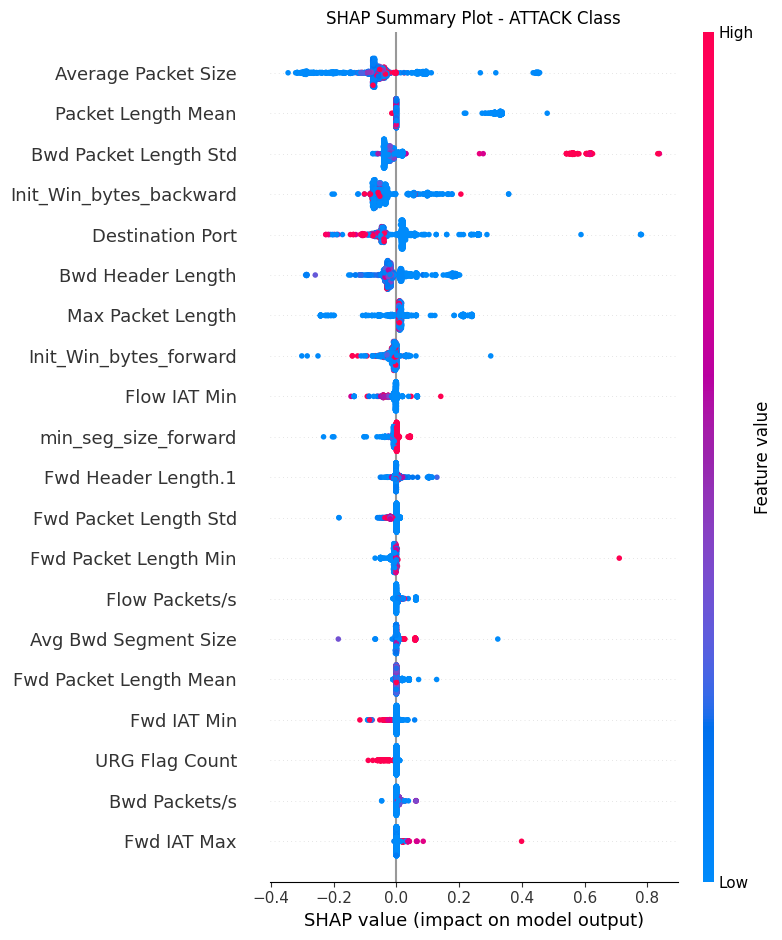

Generating SHAP Summary Plot for BENIGN class...


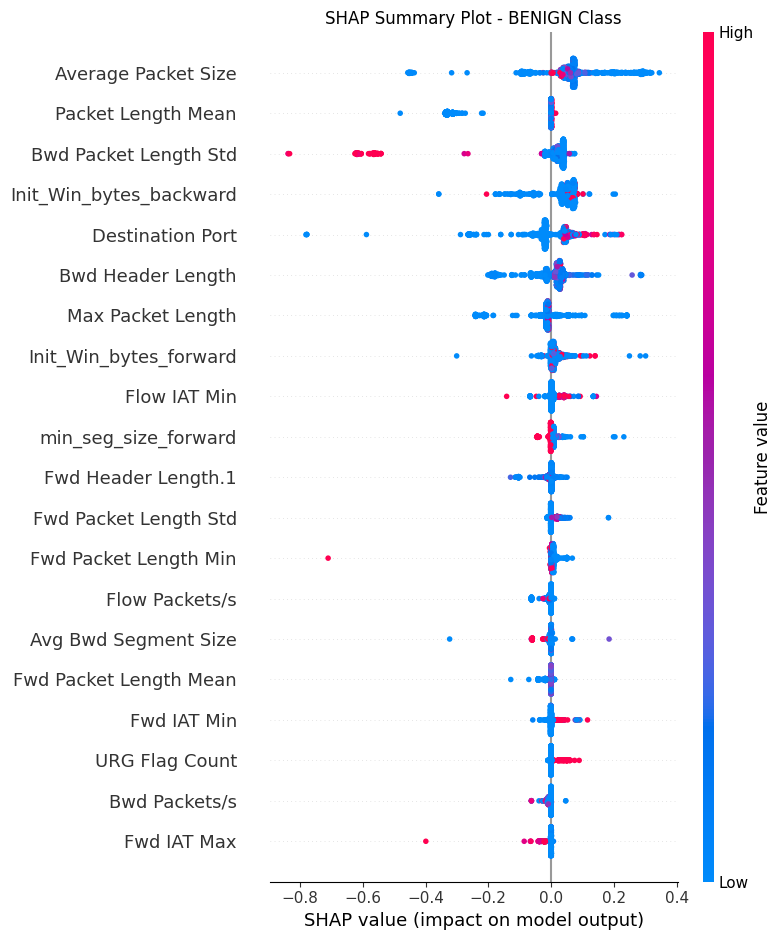

In [14]:
import shap

print("\nStarting SHAP Explainer...")

# 10. Sample the test set for SHAP to avoid massive computation times
# We use a sample of 1000 instances. You can increase this if you have more compute power.
X_test_sample = X_test.sample(n=1000, random_state=42)

# 11. Initialize the SHAP TreeExplainer
# TreeExplainer is highly optimized for tree-based models like Decision Trees
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(dt_classifier)
shap_values = explainer.shap_values(X_test_sample)

# Note: For a binary classification Decision Tree in scikit-learn, 
# shap_values is a list of two arrays: [shap_values_for_class_0, shap_values_for_class_1]
# Class 0 = BENIGN, Class 1 = ATTACK

# 12. Extract the correct SHAP values based on the output format
if isinstance(shap_values, list):
    # Older SHAP behavior
    shap_attack = shap_values[1]
    shap_benign = shap_values[0]
elif len(shap_values.shape) == 3:
    # Newer SHAP behavior: 3D array (samples, features, classes)
    shap_attack = shap_values[:, :, 1]
    shap_benign = shap_values[:, :, 0]
else:
    # Fallback if SHAP only returned a 2D array for the positive class
    shap_attack = shap_values
    shap_benign = -shap_values 

# 13. Generate SHAP Summary Plot for the ATTACK class
print("Generating SHAP Summary Plot for ATTACK class...")
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - ATTACK Class")
shap.summary_plot(shap_attack, X_test_sample, show=False)
plt.tight_layout()
plt.show()

# 14. Generate SHAP Summary Plot for the BENIGN class
print("Generating SHAP Summary Plot for BENIGN class...")
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - BENIGN Class")
shap.summary_plot(shap_benign, X_test_sample, show=False)
plt.tight_layout()
plt.show()


Initializing LIME Tabular Explainer...
Explaining BENIGN sample with LIME...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


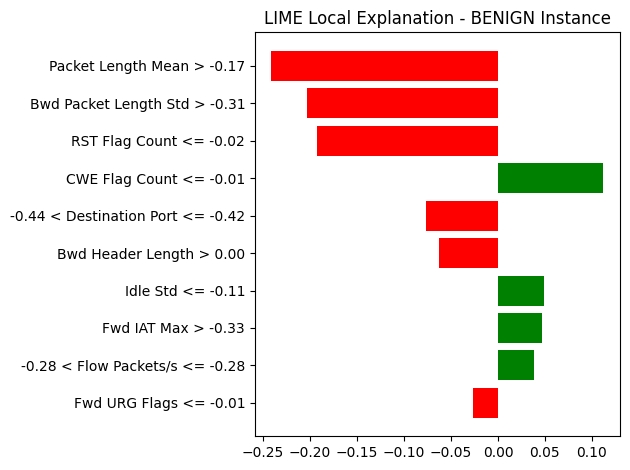

Explaining ATTACK sample with LIME...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


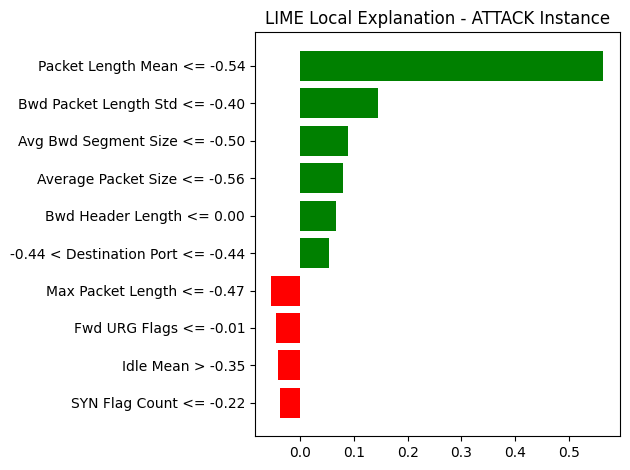

Displaying LIME for BENIGN Sample:



Displaying LIME for ATTACK Sample:


In [15]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

print("\nInitializing LIME Tabular Explainer...")

# 15. Setup the LIME Tabular Explainer
# LIME requires the training matrix to capture basic feature scale, mean, and variances
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['BENIGN (0)', 'ATTACK (1)'],
    mode='classification'
)

# 16. Isolate indices for a true benign sample and a true attack sample
# This aligns directly with the instance comparison methodologies outlined in the paper
idx_benign = y_test[y_test == 0].index[0]
idx_attack = y_test[y_test == 1].index[0]

sample_benign = X_test.loc[idx_benign].values
sample_attack = X_test.loc[idx_attack].values

# 17. Generate and plot local explanation for the BENIGN instance
print("Explaining BENIGN sample with LIME...")
exp_benign = explainer_lime.explain_instance(
    data_row=sample_benign,
    predict_fn=dt_classifier.predict_proba,
    num_features=10
)

# Plotting the feature weight distribution via matplotlib
fig_benign = exp_benign.as_pyplot_figure()
plt.title("LIME Local Explanation - BENIGN Instance")
plt.tight_layout()
plt.show()

# (Optional): If running inside a Kaggle/Jupyter Notebook, uncomment below for the rich HTML view:
# exp_benign.show_in_notebook(show_table=True)


# 18. Generate and plot local explanation for the ATTACK instance
print("Explaining ATTACK sample with LIME...")
exp_attack = explainer_lime.explain_instance(
    data_row=sample_attack,
    predict_fn=dt_classifier.predict_proba,
    num_features=10
)

fig_attack = exp_attack.as_pyplot_figure()
plt.title("LIME Local Explanation - ATTACK Instance")
plt.tight_layout()
plt.show()
# Render the interactive HTML dashboard for the BENIGN instance
print("Displaying LIME for BENIGN Sample:")
exp_benign.show_in_notebook(show_table=True, show_all=False)

# Render the interactive HTML dashboard for the ATTACK instance
print("\nDisplaying LIME for ATTACK Sample:")
exp_attack.show_in_notebook(show_table=True, show_all=False)